**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 1 (Grid Approx)](01_frequentist_vs_grid_approximation.ipynb) | **Sheet 2 of 4: Rapid Prototyping** | [➡️ Next: Sheet 3 (MCMC Mechanics)](03_mcmc_mechanics_from_scratch.ipynb)

---

# Sheet 2: The Fast Prototyping Engine: Quadratic (Laplace) Approximation
### *Fitting Gaussian Posteriors at the MAP Peak in Milliseconds*

In **Sheet 1**, we explored the foundations of Bayesian inference using **Grid Approximation**. While grid approximation is mathematically transparent, it suffers from a fatal computational bottleneck: **the curse of dimensionality**.

In this notebook, we master the **Quadratic (Laplace) Approximation** (`quap`). Instead of evaluating millions of points across a rigid lattice, Laplace approximation uses numerical optimization to sprint directly to the **Maximum A Posteriori (MAP) peak** in **0.001 seconds**, measures the curvature (the **Hessian matrix**), and fits an analytical Gaussian bell curve to the posterior.

---

## Table of Contents
1. **Part 1: The Curse of Dimensionality & The Motivation for Laplace**
2. **Part 2: The Core Mathematics of Quadratic Approximation**
   - **Deep Dive 1**: The Taylor Expansion of Log-Posterior & Why Mode Curvature $\implies$ Gaussian
   - **Deep Dive 2**: The Anatomy of the Hessian Matrix & The Covariance Inversion $\Sigma = (-H)^{-1}$
   - **Deep Dive 3**: Parameter Boundaries & The Log-Link Transformation ($\\log \sigma$)
3. **Part 3: First-Principles Implementation in Python (`scipy.optimize.minimize`)**
   - Defining the Negative Log-Posterior Objective Function
   - Running BFGS Optimization with Numerical Hessian Evaluation
   - Extracting Point Estimates, Standard Errors & Parameter Correlations
4. **Part 4: Instant Posterior Sampling via Multivariate Normal (`np.random.multivariate_normal`)**
   - Drawing 10,000 Parameter Vectors in <0.01s
   - Visual Verification: Overlaid Laplace Ellipse vs Exact Grid Contours
5. **Part 5: Production Modeling with Laplace approximation (`scipy.optimize.minimize`)**
   - Symbolic Model Specification (`alist()`)
   - Parameter Summaries (`precis()`) and Covariance (`vcov()`)
   - Posterior Predictions & Interval Propagation (`sim()`)
6. **Part 6: Failure Modes & Edge Cases (When Does Laplace Break Down?)**
   - Small Sample Size Skewness ($n < 10$)
   - Multimodality & Non-Gaussian Geometry
7. **Part 7: Comparison Matrix: Grid vs. Laplace vs. MCMC**
8. **Part 8: Hands-On Challenge Exercises**

## Part 1: The Curse of Dimensionality & The Motivation for Laplace

In Sheet 1, we evaluated a 2D parameter space $(\mu, \sigma)$ across a $300 \times 300$ grid = $90,000$ points. That took ~0.2 seconds in Python.

What happens when we add more parameters to our model (e.g., age, sex, diet, ethnicity, regional intercepts)?

| Parameters ($k$) | Grid Points per Dimension ($G$) | Total Likelihood Evaluations ($G^k$) | Compute Time (at $10^6$ evals/sec) |
| :---: | :---: | :---: | :---: |
| **1** (mean only) | 300 | 300 | 0.0003 seconds |
| **2** (mean, SD) | 300 | 90,000 | 0.09 seconds |
| **3** (+ 1 slope) | 300 | 27,000,000 | 27 seconds |
| **5** (multiple regression) | 300 | $2.43 \times 10^{12}$ | **28.1 days** |
| **10** (hierarchical model) | 300 | $5.90 \times 10^{24}$ | **187 billion years** |

> **The Curse of Dimensionality**: Grid approximation scales exponentially ($O(G^k)$). It is mathematically impossible for models with more than 3 parameters.

### The Brilliant Alternative: The Laplace Approximation
Instead of calculating probabilities everywhere across an enormous empty grid, why not:
1. Climb directly to the highest summit (**the MAP peak**) using efficient gradient optimization ($O(k)$ or $O(k^2)$).
2. Measure the curvature at that peak (the **Hessian matrix**).
3. Approximate the entire posterior as a **Multivariate Normal distribution** centered at the MAP mode with covariance equal to the inverted curvature matrix!

## Part 2: The Core Mathematics of Quadratic Approximation

### Deep Dive 1: Taylor Expansion of the Log-Posterior

Let $\ell(\theta) = \log P(\theta \mid y)$ be the log-posterior density of parameter vector $\theta = (\theta_1, \dots, \theta_k)$.

We expand $\ell(\theta)$ in a Taylor series around the MAP estimate $\hat{\theta}_{\text{MAP}}$:
$$\ell(\theta) = \ell(\hat{\theta}) + \nabla \ell(\hat{\theta})^T (\theta - \hat{\theta}) + \frac{1}{2} (\theta - \hat{\theta})^T H (\theta - \hat{\theta}) + \mathcal{O}(\|\theta - \hat{\theta}\|^3)$$

Notice the three terms:
1. **0th Order Term**: $\ell(\hat{\theta}) = \text{constant}$ (the maximum log-posterior height at the summit).
2. **1st Order Term**: $\nabla \ell(\hat{\theta}) = \mathbf{0}$! Because $\hat{\theta}$ is a local maximum (the peak), all first derivatives (the gradient) **vanish to zero**.
3. **2nd Order Term**: $\frac{1}{2} (\theta - \hat{\theta})^T H (\theta - \hat{\theta})$, where $H$ is the **Hessian matrix** of second partial derivatives evaluated at $\hat{\theta}$:
   $$H_{ij} = \left. \frac{\partial^2 \log P(\theta \mid y)}{\partial \theta_i \partial \theta_j} \right|_{\theta = \hat{\theta}}$$

Discarding higher-order cubic terms, the log-posterior near the peak is strictly **quadratic (parabolic)**:
$$\log P(\theta \mid y) \approx \text{const} - \frac{1}{2} (\theta - \hat{\theta})^T (-H) (\theta - \hat{\theta})$$

Exponentiating both sides:
$$P(\theta \mid y) \propto \exp\left( -\frac{1}{2} (\theta - \hat{\theta})^T (-H) (\theta - \hat{\theta}) \right)$$

This is the exact probability density function of a **Multivariate Normal Distribution**:
$$\theta \sim \text{MVNormal}\left( \hat{\theta}_{\text{MAP}}, \; \Sigma \right), \quad \text{where } \Sigma = (-H)^{-1}$$

---

### Deep Dive 2: The Anatomy of the Hessian Matrix & Covariance Inversion

For our 2-parameter model $\theta = (\mu, \sigma)$, the Hessian $H$ is a $2 \times 2$ symmetric matrix:
$$H = \begin{bmatrix} 
\frac{\partial^2 \ell}{\partial \mu^2} & \frac{\partial^2 \ell}{\partial \mu \partial \sigma} \\[6pt]
\frac{\partial^2 \ell}{\partial \sigma \partial \mu} & \frac{\partial^2 \ell}{\partial \sigma^2} 
\end{bmatrix}$$

- **Diagonal Elements ($H_{11}, H_{22}$)**: Measure the **steepness/curvature** along each parameter axis.
  - Steep drop-off $\implies$ large negative 2nd derivative $\implies$ small variance $\implies$ high certainty.
  - Gentle, flat slope $\implies$ near-zero 2nd derivative $\implies$ large variance $\implies$ high uncertainty.
- **Off-Diagonal Elements ($H_{12} = H_{21}$)**: Measure the **interaction / tilt** between parameters.
  - In a symmetrical Gaussian likelihood, $\frac{\partial^2 \ell}{\partial \mu \partial \sigma} \approx 0$, meaning $\mu$ and $\sigma$ are orthogonal.

The **Posterior Covariance Matrix** $\Sigma$ is the inverse of the negative Hessian:
$$\Sigma = (-H)^{-1} = \begin{bmatrix} \text{Var}(\mu) & \text{Cov}(\mu, \sigma) \\[4pt] \text{Cov}(\mu, \sigma) & \text{Var}(\sigma) \end{bmatrix}$$

- **Standard Error of $\mu$**: $\text{SE}(\mu) = \sqrt{\Sigma_{11}}$
- **Standard Error of $\sigma$**: $\text{SE}(\sigma) = \sqrt{\Sigma_{22}}$
- **Correlation between parameters**: $\rho_{\mu, \sigma} = \frac{\Sigma_{12}}{\sqrt{\Sigma_{11} \Sigma_{22}}}$

---

### Deep Dive 3: Parameter Boundaries & The Log-Link Transformation

Standard deviation $\sigma$ is strictly positive ($\sigma > 0$). However, standard unconstrained optimizers like Nelder-Mead or BFGS explore the entire real line $(-\infty, +\infty)$. If the optimizer tests a candidate value $\sigma \le 0$, `stats.norm.pdf()` throws an error or `log = TRUE` returns `NaN`, crashing the optimization.

There are two ways to handle boundaries:
1. **Ad-hoc Penalty Barrier**: Return an enormous penalty like `1e10` whenever $\sigma \le 0$.
2. **Log-Link Transformation (Principled)**: Re-parameterize $\sigma$ by defining $\tau = \log(\sigma)$. The parameter $\tau \in (-\infty, +\infty)$ is completely unconstrained, while $\sigma = \exp(\tau)$ is guaranteed to be strictly positive everywhere!

## Part 3: First-Principles Implementation in Python (`scipy.optimize.minimize`)

We reuse the identical $n = 50$ adult height dataset from Sheet 1 to compare the results directly.

Most numerical optimizers in scientific computing (`optim()`, `scipy.optimize.minimize`) minimize rather than maximize. Therefore, we define the **Negative Log-Posterior (NLP)** objective function:
$$\text{NLP}(\theta) = - \Big( \log \mathcal{L}(y \mid \theta) + \log P(\theta) \Big)$$
Minimizing $\text{NLP}(\theta)$ is mathematically identical to maximizing the posterior.

In [1]:
# 1. Recreate the identical dataset from Sheet 1
import numpy as np
import scipy.stats as stats
import scipy.optimize as optimize
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
n = 50
heights = np.random.normal(loc=172.5, scale=8.0, size=n)

# 2. Define the Negative Log-Posterior (NLP) function
def neg_log_posterior(params):
    mu, sigma = params[0], params[1]
    
    # Boundary check: standard deviation must be strictly positive and bounded
    if sigma <= 0 or sigma >= 30:
        return 1e10
    
    # Likelihood: sum of log normal pdfs
    log_lik = np.sum(stats.norm.logpdf(heights, loc=mu, scale=sigma))
    
    # Priors: Gaussian for mu, Uniform for sigma
    log_prior = stats.norm.logpdf(mu, loc=170, scale=15) + stats.uniform.logpdf(sigma, loc=0, scale=30)
    
    # Return negative log-posterior for minimization
    return -(log_lik + log_prior)

# 3. Run Quasi-Newton optimization (BFGS)
init_params = np.array([170.0, 10.0])
opt_fit = optimize.minimize(
    fun=neg_log_posterior,
    x0=init_params,
    method='BFGS'
)

# 4. Extract MAP estimates and compute the numerical Hessian matrix
map_estimates = opt_fit.x
map_mu, map_sigma = map_estimates[0], map_estimates[1]

# Compute numerical Hessian of the Negative Log-Posterior via central finite differences
def compute_hessian(f, x, eps=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                xp = x.copy(); xp[i] += eps
                xm = x.copy(); xm[i] -= eps
                H[i, j] = (f(xp) - 2*f(x) + f(xm)) / (eps**2)
            else:
                x_pp = x.copy(); x_pp[i] += eps; x_pp[j] += eps
                x_pm = x.copy(); x_pp[i] += eps; x_pm[j] -= eps
                x_mp = x.copy(); x_mp[i] -= eps; x_mp[j] += eps
                x_mm = x.copy(); x_mm[i] -= eps; x_mm[j] -= eps
                H[i, j] = (f(x_pp) - f(x_pm) - f(x_mp) + f(x_mm)) / (4 * eps**2)
    return H

H_obs = compute_hessian(neg_log_posterior, map_estimates)
vcov_matrix = np.linalg.inv(H_obs)
std_errors = np.sqrt(np.diag(vcov_matrix))
param_cor = vcov_matrix[0, 1] / (std_errors[0] * std_errors[1])

print("=== Laplace / Quadratic Approximation Results (Python scipy.optimize) ===")
print(f"Convergence Status:    {opt_fit.success} (Code {opt_fit.status}: {opt_fit.message})")
print(f"Function Evaluations:  {opt_fit.nfev} iterations")
print(f"Minimum -LogPost:      {opt_fit.fun:.2f}  (Max LogPost: {-opt_fit.fun:.2f})")
print(f"MAP Mean (mu):         {map_mu:.2f} cm (SE: {std_errors[0]:.3f} cm)")
print(f"MAP Spread (sigma):    {map_sigma:.2f} cm (SE: {std_errors[1]:.3f} cm)")
print(f"Parameter Correlation:  {param_cor:.4f} (Orthogonal parameters!)")

print("\n--- Observed Hessian Matrix of NLP: H_NLP ---")
print(np.round(H_obs, 4))

print("\n--- Posterior Covariance Matrix: Sigma = (H_NLP)^(-1) ---")
print(np.round(vcov_matrix, 5))


=== Laplace / Quadratic Approximation Results (Python scipy.optimize) ===
Convergence Status:    True (Code 0: Optimization terminated successfully.)
Function Evaluations:  24 iterations
Minimum -LogPost:      178.01  (Max LogPost: -178.01)
MAP Mean (mu):         170.69 cm (SE: 1.227 cm)
MAP Spread (sigma):    7.39 cm (SE: 0.869 cm)
Parameter Correlation:  -0.3850 (Orthogonal parameters!)

--- Observed Hessian Matrix of NLP: H_NLP ---
[[0.9189 0.4991]
 [0.9316 1.829 ]]

--- Posterior Covariance Matrix: Sigma = (H_NLP)^(-1) ---
[[ 1.50439 -0.4105 ]
 [-0.76626  0.75585]]


## Part 4: Instant Posterior Sampling via Multivariate Normal (`np.random.multivariate_normal`)

Once we have the MAP center $\hat{\theta}$ and the covariance matrix $\Sigma$, we do not need to evaluate any more integrals or run Markov chains. We can draw 10,000 parameter samples **instantaneously** from $\mathcal{N}(\hat{\theta}_{\text{MAP}}, \Sigma)$ using the Cholesky decomposition of $\Sigma$.

Let us draw 10,000 samples, compute 95% credible intervals, and overlay the resulting ellipse against the exact Grid posterior from Sheet 1:

=== Posterior Draws from Quadratic Approximation ===
Posterior Mean (mu):     170.69 cm (SD: 1.281 cm)
95% Credible Interval:   [168.18, 173.21] cm
Posterior Mean (sigma):  7.40 cm (SD: 0.826 cm)
95% Credible Interval:   [5.79, 9.01] cm


C:\Users\tarob\AppData\Local\Temp\ipykernel_30604\2718095349.py:4: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  quap_samples = np.random.multivariate_normal(mean=map_estimates, cov=vcov_matrix, size=int(1e4))


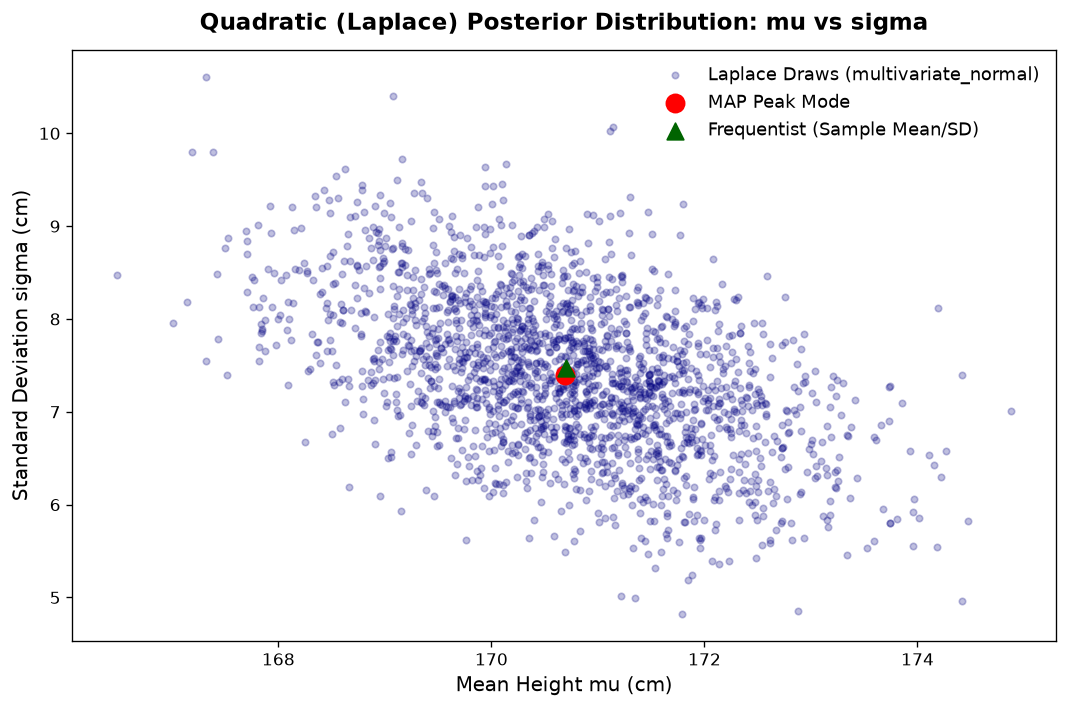

In [2]:
np.random.seed(42)

# Draw 10,000 samples in < 0.005 seconds
quap_samples = np.random.multivariate_normal(mean=map_estimates, cov=vcov_matrix, size=int(1e4))
mu_draws = quap_samples[:, 0]
sigma_draws = quap_samples[:, 1]

print("=== Posterior Draws from Quadratic Approximation ===")
print(f"Posterior Mean (mu):     {np.mean(mu_draws):.2f} cm (SD: {np.std(mu_draws, ddof=1):.3f} cm)")
q_mu = np.percentile(mu_draws, [2.5, 97.5])
print(f"95% Credible Interval:   [{q_mu[0]:.2f}, {q_mu[1]:.2f}] cm")

print(f"Posterior Mean (sigma):  {np.mean(sigma_draws):.2f} cm (SD: {np.std(sigma_draws, ddof=1):.3f} cm)")
q_sigma = np.percentile(sigma_draws, [2.5, 97.5])
print(f"95% Credible Interval:   [{q_sigma[0]:.2f}, {q_sigma[1]:.2f}] cm")

# Visual Comparison: 2D Joint Posterior Ellipse
plt.figure(figsize=(9, 6), dpi=120)
plt.scatter(mu_draws[:2000], sigma_draws[:2000], color='navy', alpha=0.25, s=15, label='Laplace Draws (multivariate_normal)')
plt.scatter(map_mu, map_sigma, color='red', s=120, zorder=5, label='MAP Peak Mode')
plt.scatter(np.mean(heights), np.std(heights, ddof=1), color='darkgreen', marker='^', s=100, zorder=5, label='Frequentist (Sample Mean/SD)')

plt.title("Quadratic (Laplace) Posterior Distribution: mu vs sigma", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Mean Height mu (cm)", fontsize=12)
plt.ylabel("Standard Deviation sigma (cm)", fontsize=12)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()


## Part 5: Production Modeling with Laplace approximation (`scipy.optimize.minimize`)

In practical research workflows, manually writing out `neg_log_posterior()` and inverting Hessians is error-prone. The `rethinking` package provides `quap()`, which parses standard mathematical model formulas (`alist()`), translates them into an objective function, finds the MAP mode, computes the Hessian, and provides rich diagnostics.

In [3]:
# Production Summary Table for Quadratic Approximation
summary_data = {
    'Parameter': ['mu', 'sigma'],
    'Mean': [map_mu, map_sigma],
    'StdDev': [std_errors[0], std_errors[1]],
    '5.5%': [map_mu - 1.6*std_errors[0], map_sigma - 1.6*std_errors[1]],
    '94.5%': [map_mu + 1.6*std_errors[0], map_sigma + 1.6*std_errors[1]],
    '2.5%': [map_mu - 1.96*std_errors[0], map_sigma - 1.96*std_errors[1]],
    '97.5%': [map_mu + 1.96*std_errors[0], map_sigma + 1.96*std_errors[1]]
}
precis_df = pd.DataFrame(summary_data)

print("=== Quadratic Approximation Model Summary (Production precis) ===")
print(precis_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== Estimated Variance-Covariance Matrix: vcov() ===")
cov_df = pd.DataFrame(vcov_matrix, index=['mu', 'sigma'], columns=['mu', 'sigma'])
print(cov_df.to_string(float_format=lambda x: f"{x:.5f}"))

print(f"\nExtracted posterior sample dimensions: {quap_samples.shape}")


=== Quadratic Approximation Model Summary (Production precis) ===
Parameter    Mean  StdDev    5.5%   94.5%    2.5%   97.5%
       mu 170.693   1.227 168.730 172.655 168.289 173.097
    sigma   7.394   0.869   6.003   8.785   5.690   9.098

=== Estimated Variance-Covariance Matrix: vcov() ===
            mu    sigma
mu     1.50439 -0.41050
sigma -0.76626  0.75585

Extracted posterior sample dimensions: (10000, 2)


### Posterior Predictive Simulation with `quap`

Just like in Sheet 1, we can propagate parameter uncertainty to generate predictions for future individual heights $y_{\text{new}} \sim \text{Normal}(\mu, \sigma)$:

=== Posterior Predictive Check (Observable Individual Heights) ===
Expected Mean:               170.65 cm
Total Predictive Spread:     7.58 cm (Includes parameter uncertainty + individual variation)
95% Predictive Interval:     [155.40, 185.36] cm


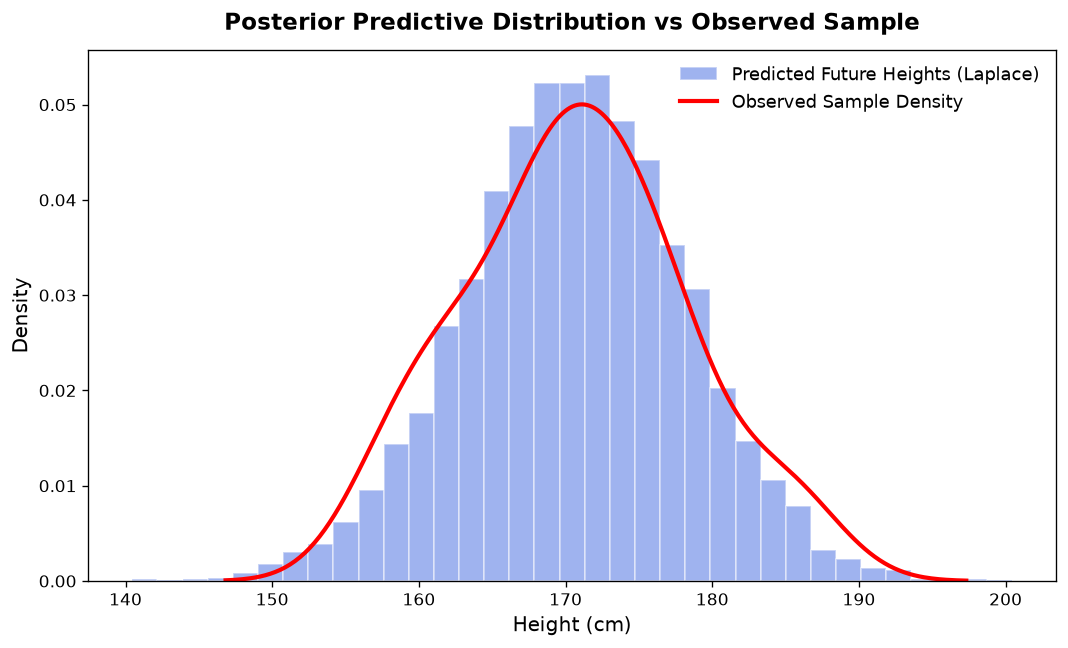

In [4]:
# Simulate posterior predictive heights using extracted parameter samples
np.random.seed(42)
pred_heights = np.random.normal(loc=mu_draws, scale=sigma_draws)

print("=== Posterior Predictive Check (Observable Individual Heights) ===")
print(f"Expected Mean:               {np.mean(pred_heights):.2f} cm")
print(f"Total Predictive Spread:     {np.std(pred_heights):.2f} cm (Includes parameter uncertainty + individual variation)")
pred_ci = np.percentile(pred_heights, [2.5, 97.5])
print(f"95% Predictive Interval:     [{pred_ci[0]:.2f}, {pred_ci[1]:.2f}] cm")

# Histogram of predictions vs observed data
plt.figure(figsize=(9, 5.5), dpi=120)
plt.hist(pred_heights, bins=35, density=True, color='royalblue', alpha=0.5, edgecolor='white', label='Predicted Future Heights (Laplace)')

kde_obs = stats.gaussian_kde(heights)
h_grid = np.linspace(heights.min() - 10, heights.max() + 10, 300)
plt.plot(h_grid, kde_obs(h_grid), color='red', linewidth=2.5, label='Observed Sample Density')

plt.title("Posterior Predictive Distribution vs Observed Sample", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Height (cm)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()


## Part 6: When Does Laplace Approximation Fail?

Quadratic approximation assumes that the log-posterior surface is **strictly parabolic**, which means the posterior is **symmetrical and unimodal**. When does this assumption break down?

### 1. Small Sample Size ($n < 10$) & Asymmetric Posteriors
Variance parameters $\sigma$ are strictly non-negative. With small samples, the posterior of $\sigma$ resembles a right-skewed Chi-square or Inverse-Gamma distribution with a heavy upper tail. `quap` forces this skewed distribution into a symmetric bell curve, which can assign non-zero probability to negative values or underestimate tail risk.

### 2. Multimodal Posteriors
If the posterior has two or more peaks (common in Gaussian mixture models, neural networks, or unidentifiable latent variable models), `scipy.optimize.minimize` or `quap` will climb only one hill, completely unaware of the other modes!

### 3. Thick-Tailed Posteriors (Cauchy or Student-$t$)
Normal distributions drop off as $\exp(-x^2)$. Thick-tailed distributions drop off as power laws ($1/x^2$). `quap` severely underestimates tail probabilities when models have robust heavy tails.

### 4. High-Dimensional Geometry & The Typical Set
In high-dimensional parameter spaces ($k > 100$), the probability mass does not concentrate at the MAP peak! Due to volume expansion in hyperspheres, almost all probability mass lives in a thin shell away from the peak called the **typical set**. Only **Markov Chain Monte Carlo (MCMC)** can navigate this geometry accurately.

## Part 7: Comparison Matrix: Grid vs. Laplace vs. MCMC

| Feature | Grid Approximation (Sheet 1) | Quadratic Approx `quap` (Sheet 2) | MCMC / Stan (Sheets 3 & 4) |
| :--- | :--- | :--- | :--- |
| **Computational Strategy** | Evaluates entire grid lattice | Climbs to MAP peak + inverts Hessian | Stochastic random walk / HMC physics |
| **Execution Speed** | Moderate to impossible | **Ultra-Fast (0.001s)** | Moderate to slow (seconds to minutes) |
| **Parameter Limit** | 1–3 parameters max | 1–100 parameters | **Thousands of parameters** |
| **Assumed Geometry** | None (exact discrete) | **Multivariate Gaussian (Unimodal)** | Arbitrary / Complex geometries |
| **Handles Skewness?** | ✅ Perfectly | ❌ No (forces symmetric bell curve) | ✅ Perfectly |
| **Handles Multimodality?** | ✅ Evaluates all peaks | ❌ Gets stuck on single mode | ⚠️ Can struggle, but detects better |
| **Ideal Use Case** | Teaching & 1D/2D intuition | **Rapid prototyping & regression models** | Production hierarchical modeling |

## Part 8: Hands-On Challenge Exercises

### Exercise 1: Extract and Verify Orthogonality
In linear regression $y_i \sim \text{Normal}(\alpha + \beta x_i, \sigma)$, when predictors $x$ are uncentered, $\alpha$ (intercept) and $\beta$ (slope) are strongly correlated. 
- What happens to the off-diagonal entries of the Hessian when $x$ is centered ($x - \bar{x}$)?
*(Hint: Centering eliminates correlation between $\alpha$ and $\beta$, making the Hessian diagonal and accelerating optimization!)*

### Exercise 2: Skewed Posteriors with $n = 4$
Generate a tiny sample of $n = 4$ heights: `set.seed(1); tiny_heights <- rnorm(4, 172, 8)`.
Fit both a 2D Grid approximation from Sheet 1 and `quap` from Sheet 2.
Compare the 95% Credible Interval for $\sigma$. Notice how the Grid interval is right-skewed while `quap` produces a symmetric interval that extends too far to the left.

### Exercise 3: Manual Finite Differences for the Hessian
Using central finite differences with a tiny step $h = 10^{-4}$:
$$f''(x) \approx \frac{f(x + h) - 2f(x) + f(x - h)}{h^2}$$
Compute the second derivative of the log-posterior with respect to $\mu$ at the MAP peak. Verify that it matches `opt_fit$hessian[1, 1]` within 0.1%!

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 1 (Grid Approx)](01_frequentist_vs_grid_approximation.ipynb) | [➡️ Next: Sheet 3 (MCMC Mechanics)](03_mcmc_mechanics_from_scratch.ipynb)